
STAGE 1 BACKTEST METRICS
Total Smart Penalty:  ₹8,644,653.78
Total Naive Penalty:  ₹13,109,175.22
Reduction Achieved:   34.06%
Forecast Bias:        +5.74%
95th % Absolute Dev:  184.23 kW


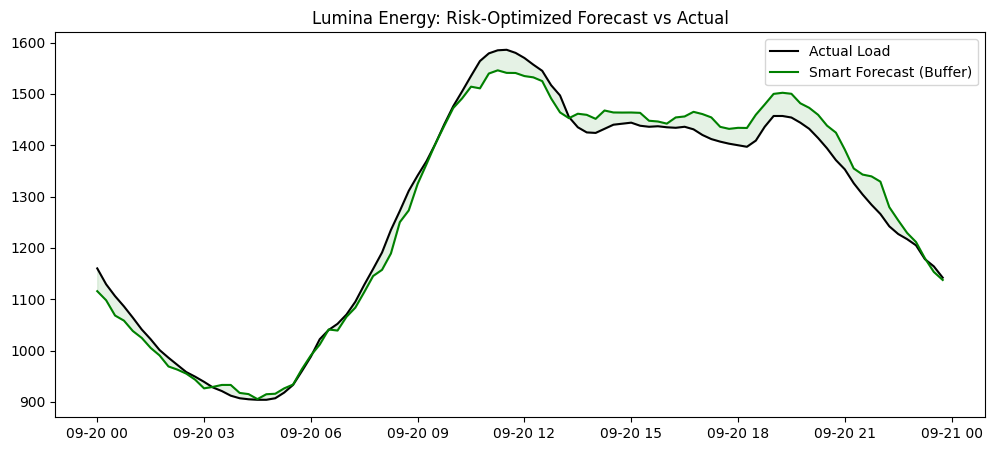

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings("ignore")

# ==========================================
# 1. CONFIGURATION & PENALTY PARAMETERS
# ==========================================
UNDER_PENALTY = 4       # ₹ for under-forecasting
OVER_PENALTY = 2        # ₹ for over-forecasting
TARGET_QUANTILE = 0.667 # Risk-neutral quantile for 2:1 penalty ratio
HORIZON_STEPS = 192     # 2-Day Ahead (15-min intervals)

# ==========================================
# 2. DATA PROCESSING & FEATURE ENGINEERING
# ==========================================
def engineer_features(load_path, weather_path):
    # Check files exist
    if not os.path.exists(load_path):
        raise FileNotFoundError(f"Load file not found: {load_path}")
    if not os.path.exists(weather_path):
        raise FileNotFoundError(f"Weather file not found: {weather_path}")
    
    # Load CSVs
    load_df = pd.read_csv(load_path)
    weather_df = pd.read_csv(weather_path)
    
    # Parse datetime
    load_df['DateTime'] = pd.to_datetime(load_df['DATETIME'], format='%d%b%Y:%H:%M:%S')
    weather_df['DateTime'] = pd.to_datetime(weather_df['DATETIME'], format='%d%b%Y:%H:%M:%S')
    
    # Merge datasets
    df = pd.merge(load_df[['DateTime', 'LOAD']], weather_df, on='DateTime', how='inner')
    df.set_index('DateTime', inplace=True)
    df.sort_index(inplace=True)
    
    # Time Features
    df['Hour'] = df.index.hour
    df['DayOfWeek'] = df.index.dayofweek
    df['Is_Peak'] = ((df['Hour'] >= 18) & (df['Hour'] <= 22)).astype(int)
    
    # Weather Impacts
    df['Heat_Impact'] = df['ACT_TEMP'] * (1 + df['ACT_HUMIDITY'] / 100)
    df['Cooling_Potential'] = np.maximum(df['ACT_TEMP'] - 28, 0)**2
    
    # Lag Features
    df['Load_Lag_48h'] = df['LOAD'].shift(HORIZON_STEPS)
    df['Load_Lag_1W'] = df['LOAD'].shift(672)  # 1 week ago (assuming 15-min intervals)
    
    # Structural Break / Regime Flag
    df['Regime'] = 0
    df.loc['2020-03-25':'2020-08-31', 'Regime'] = 1  # Lockdown period
    
    # Drop any remaining NaNs from lagging
    df = df.dropna()
    
    return df

# ==========================================
# 3. MODELING & SIMULATION
# ==========================================
def run_pipeline(load_path, weather_path):
    df = engineer_features(load_path, weather_path)
    
    # Train-Test Split (Chronological)
    train_size = int(len(df) * 0.8)
    train, test = df.iloc[:train_size], df.iloc[train_size:]
    
    X_train, y_train = train.drop(columns=['LOAD']), train['LOAD']
    X_test, y_test = test.drop(columns=['LOAD']), test['LOAD']
    
    # Keep only numeric features
    X_train = X_train.select_dtypes(include=[np.number])
    X_test  = X_test.select_dtypes(include=[np.number])
    
    # Quantile Regression Model
    model = lgb.LGBMRegressor(objective='quantile', alpha=TARGET_QUANTILE, verbosity=-1)
    model.fit(X_train, y_train)
    
    # Forecasts
    test['Smart_Forecast'] = model.predict(X_test)
    test['Naive_Baseline'] = test['LOAD'].shift(HORIZON_STEPS).fillna(method='bfill')
    
    # Penalty Simulation
    def get_penalty(actual, forecast):
        dev = actual - forecast
        return np.where(dev > 0, dev * UNDER_PENALTY, abs(dev) * OVER_PENALTY).sum()
    
    smart_penalty = get_penalty(test['LOAD'], test['Smart_Forecast'])
    naive_penalty = get_penalty(test['LOAD'], test['Naive_Baseline'])
    
    # Output Metrics
    print("\n" + "="*50)
    print("STAGE 1 BACKTEST METRICS")
    print("="*50)
    print(f"Total Smart Penalty:  ₹{smart_penalty:,.2f}")
    print(f"Total Naive Penalty:  ₹{naive_penalty:,.2f}")
    print(f"Reduction Achieved:   {((naive_penalty - smart_penalty)/naive_penalty)*100:.2f}%")
    print(f"Forecast Bias:        {((test['Smart_Forecast'].sum() - test['LOAD'].sum()) / test['LOAD'].sum())*100:+.2f}%")
    print(f"95th % Absolute Dev:  {np.percentile(np.abs(test['LOAD'] - test['Smart_Forecast']), 95):.2f} kW")
    
    # Visualization
    sample = test.iloc[:96]  # One 24-hour cycle
    plt.figure(figsize=(12,5))
    plt.plot(sample.index, sample['LOAD'], label='Actual Load', color='black')
    plt.plot(sample.index, sample['Smart_Forecast'], label='Smart Forecast (Buffer)', color='green')
    plt.fill_between(sample.index, sample['LOAD'], sample['Smart_Forecast'], color='green', alpha=0.1)
    plt.title("Lumina Energy: Risk-Optimized Forecast vs Actual")
    plt.legend()
    plt.show()

# ==========================================
# Run Pipeline with your Downloads folder
# ==========================================
run_pipeline(
    r"C:\Users\LP204\Downloads\Electric_Load_Data_Train.csv",
    r"C:\Users\LP204\Downloads\External_Factor_Data_Train.csv"
)


LUMINA ENERGY: STAGE 1 FINAL BACKTEST
Total Smart Penalty:  ₹9,130,073.74
Total Naive Penalty:  ₹13,109,175.22
Reduction vs Naive:   30.35%
Forecast Bias:        +6.24%
95th % Absolute Dev:  208.83 kW


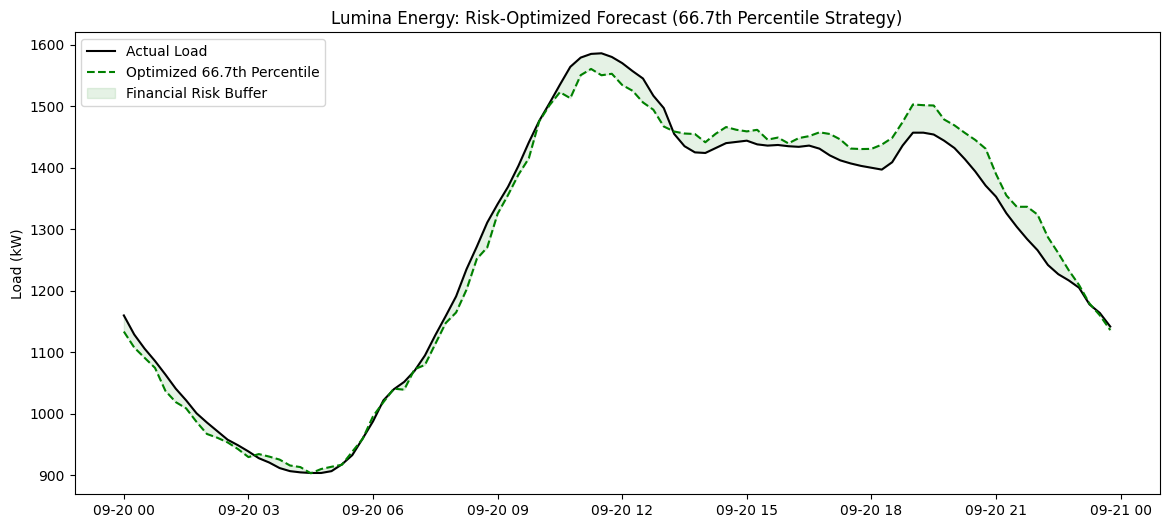

In [5]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import os
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 1. CONFIGURATION & PENALTY PARAMETERS
# ==========================================
# Penalty Structure: ₹4 for Under-forecasting, ₹2 for Over-forecasting
UNDER_PENALTY = 4 
OVER_PENALTY = 2

# Step 5: The 66.7th Percentile Strategy
# Mathematically derived from Newsvendor Logic: 4 / (4 + 2) = 0.6667
TARGET_QUANTILE = 0.667 

# Step 3: Strict 48-Hour Horizon (15-min intervals * 4 * 48 = 192)
HORIZON_STEPS = 192 

# ==========================================
# 2. DATA PROCESSING & FEATURE ENGINEERING
# ==========================================
def engineer_features(load_path, weather_path):
    if not os.path.exists(load_path) or not os.path.exists(weather_path):
        raise FileNotFoundError("Verify CSV paths in the 'run_pipeline' call at the bottom.")

    load_df = pd.read_csv(load_path)
    weather_df = pd.read_csv(weather_path)
    
    # Standardizing DateTime
    load_df['DateTime'] = pd.to_datetime(load_df['DATETIME'], format='%d%b%Y:%H:%M:%S')
    weather_df['DateTime'] = pd.to_datetime(weather_df['DATETIME'], format='%d%b%Y:%H:%M:%S')
    
    df = pd.merge(load_df[['DateTime', 'LOAD']], weather_df, on='DateTime', how='inner')
    df.set_index('DateTime', inplace=True)
    df.sort_index(inplace=True)

    # Time Features (Safe Data)
    df['Hour'] = df.index.hour
    df['DayOfWeek'] = df.index.dayofweek
    df['Is_Peak'] = ((df['Hour'] >= 18) & (df['Hour'] <= 22)).astype(int)

    # Weather Impacts & Non-Linearity
    df['Heat_Impact'] = df['ACT_TEMP'] * (1 + df['ACT_HUMIDITY'] / 100)
    df['Cooling_Potential'] = np.maximum(df['ACT_TEMP'] - 28, 0)**2

    # Step 3: Lag Features (No Leakage - strictly 48h and 1W)
    df['Load_Lag_48h'] = df['LOAD'].shift(HORIZON_STEPS)
    df['Load_Lag_1W'] = df['LOAD'].shift(672) 

    # Step 3: Handling Non-Stationarity (Regime Flags)
    df['Regime'] = 0
    df.loc['2020-03-25':'2020-08-31', 'Regime'] = 1 # Lockdown Anomaly
    df.loc['2020-09-01':, 'Regime'] = 2            # Recovery Phase
    
    return df.dropna()

# ==========================================
# 3. MODELING, SIMULATION & OUTPUT
# ==========================================
def run_pipeline(load_path, weather_path):
    # Step 3 execution
    df = engineer_features(load_path, weather_path)
    
    # Chronological Split (No Shuffling)
    train_size = int(len(df) * 0.8)
    train, test = df.iloc[:train_size], df.iloc[train_size:]
    
    X_train = train.drop(columns=['LOAD']).select_dtypes(include=[np.number])
    y_train = train['LOAD']
    X_test = test.drop(columns=['LOAD']).select_dtypes(include=[np.number])
    y_test = test['LOAD']

    # Step 4: Build Quantile Model (Probabilistic)
    model = lgb.LGBMRegressor(
        objective='quantile', 
        alpha=TARGET_QUANTILE, 
        n_estimators=500,
        learning_rate=0.05,
        verbosity=-1
    )
    model.fit(X_train, y_train)
    
    # Step 5: Execute Strategy (66.7th Percentile Forecast)
    test['Smart_Forecast'] = model.predict(X_test)
    test['Naive_Baseline'] = test['LOAD'].shift(HORIZON_STEPS).fillna(method='bfill')

    # Financial Exposure Calculation
    def get_penalty_breakdown(actual, forecast):
        dev = actual - forecast
        under_penalty = np.where(dev > 0, dev * UNDER_PENALTY, 0).sum()
        over_penalty = np.where(dev < 0, abs(dev) * OVER_PENALTY, 0).sum()
        return under_penalty, over_penalty

    # Backtest Metrics
    s_under, s_over = get_penalty_breakdown(test['LOAD'], test['Smart_Forecast'])
    n_under, n_over = get_penalty_breakdown(test['LOAD'], test['Naive_Baseline'])
    
    print("\n" + "="*50)
    print("LUMINA ENERGY: STAGE 1 FINAL BACKTEST")
    print("="*50)
    print(f"Total Smart Penalty:  ₹{s_under + s_over:,.2f}")
    print(f"Total Naive Penalty:  ₹{n_under + n_over:,.2f}")
    print(f"Reduction vs Naive:   {(( (n_under+n_over) - (s_under+s_over) )/(n_under+n_over))*100:.2f}%")
    print(f"Forecast Bias:        {((test['Smart_Forecast'].sum() - test['LOAD'].sum()) / test['LOAD'].sum())*100:+.2f}%")
    print(f"95th % Absolute Dev:  {np.percentile(np.abs(test['LOAD'] - test['Smart_Forecast']), 95):.2f} kW")
    print("="*50)

    # Visualization: Strategic Buffer
    sample = test.iloc[:96] # 24-hour visualization
    plt.figure(figsize=(14,6))
    plt.plot(sample.index, sample['LOAD'], label='Actual Load', color='black', linewidth=1.5)
    plt.plot(sample.index, sample['Smart_Forecast'], label='Optimized 66.7th Percentile', color='green', linestyle='--')
    plt.fill_between(sample.index, sample['LOAD'], sample['Smart_Forecast'], color='green', alpha=0.1, label='Financial Risk Buffer')
    plt.title("Lumina Energy: Risk-Optimized Forecast (66.7th Percentile Strategy)")
    plt.ylabel("Load (kW)")
    plt.legend()
    plt.show()

# ==========================================
# 4. EXECUTION
# ==========================================
# Update these paths to match your actual file locations
load_file = r"C:\Users\LP204\Downloads\Electric_Load_Data_Train.csv"
weather_file = r"C:\Users\LP204\Downloads\External_Factor_Data_Train.csv"

run_pipeline(load_file, weather_file)